# Gold Futures (GC) — Statistical Engine
## Columbia University | IEOR4703 Monte Carlo Simulation Methods

This notebook implements the volatility-volume-based order management statistical engine for **Gold Futures (GC)**.

**Key parameters:**
- Tick size: 0.10
- Session length: 1,380 min/day
- Contracts: GCG24, GCJ24, GCM24, GCQ24
- Holding period τ: 5 minutes
- Target fill probability: 70%

**Outputs:**
- `GC_clean.csv` — cleaned and stitched 1-minute OHLCV data
- `GC_signals_with_recommendations.csv` — limit order recommendations for all signals

In [13]:
import pandas as pd

def load_and_clean(filepath):
    # Step 1: Load raw data 
    df = pd.read_csv(
        filepath,
        header=None,
        names=["datetime", "open", "high", "low", "close", "volume"]
    )
    
    df["contract"] = filepath.split("/")[-1].replace(".csv", "")

    # Parse datetime
    df["datetime"] = pd.to_datetime(
        df["datetime"],
        format="%Y.%m.%d.%H:%M:%S"
    )

    # Step 2: Filter low-liquidity days
    df["date"] = df["datetime"].dt.date

    df["bars_per_day"] = df.groupby("date")["datetime"].transform("count")

    df_clean = df[df["bars_per_day"] > 1242].copy()

    # Step 3: OHLCV sanity checks
    valid_ohlc = (
        (df_clean["high"] >= df_clean["low"]) &
        (df_clean["open"] >= df_clean["low"]) &
        (df_clean["open"] <= df_clean["high"]) &
        (df_clean["close"] >= df_clean["low"]) &
        (df_clean["close"] <= df_clean["high"]) &
        (df_clean["volume"] > 0)
    )

    df_clean = df_clean[valid_ohlc].copy()

    return df_clean

In [14]:
files = [
    "data/Gold/GCG24.csv",
    "data/Gold/GCJ24.csv",
    "data/Gold/GCM24.csv",
    "data/Gold/GCQ24.csv"
]

all_dfs = [load_and_clean(f) for f in files]

df_all = pd.concat(all_dfs)

df_all = df_all.sort_values("datetime").reset_index(drop=True)

print(df_all["contract"].value_counts())

print("Total liquid days:", df_all["date"].nunique())

contract
GCM24    52243
GCQ24    46703
GCJ24    46686
GCG24    45483
Name: count, dtype: int64
Total liquid days: 132


In [15]:
# Compute daily volume per contract
daily_vol = df_all.groupby(["date", "contract"])["volume"].sum().reset_index()

# For each date, find the contract with highest volume
best_contract = daily_vol.loc[
    daily_vol.groupby("date")["volume"].idxmax(),
    ["date", "contract"]
]

# Keep only rows from the winning contract each day
df_stitched = df_all.merge(
    best_contract,
    on=["date", "contract"]
).reset_index(drop=True)

print(df_stitched["contract"].value_counts())
print("Total days after stitching:", df_stitched["date"].nunique())

contract
GCM24    48226
GCG24    45483
GCJ24    44048
GCQ24    44030
Name: count, dtype: int64
Total days after stitching: 132


In [16]:
print(df_stitched.groupby("contract")["date"].agg(["min", "max"]))

                 min         max
contract                        
GCG24     2023-11-27  2024-01-25
GCJ24     2024-01-29  2024-03-25
GCM24     2024-03-26  2024-05-28
GCQ24     2024-05-29  2024-07-25


In [17]:
df_stitched = df_stitched.drop(columns=["bars_per_day"])
df_stitched = df_stitched.reset_index(drop=True)
print(df_stitched.info())

<class 'pandas.DataFrame'>
RangeIndex: 181787 entries, 0 to 181786
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   datetime  181787 non-null  datetime64[us]
 1   open      181787 non-null  float64       
 2   high      181787 non-null  float64       
 3   low       181787 non-null  float64       
 4   close     181787 non-null  float64       
 5   volume    181787 non-null  int64         
 6   contract  181787 non-null  str           
 7   date      181787 non-null  object        
dtypes: datetime64[us](1), float64(4), int64(1), object(1), str(1)
memory usage: 11.1+ MB
None


In [18]:
# STEP 2


In [19]:
# Compute range features in ticks
df_stitched["range_ticks"] = (
    (df_stitched["high"] - df_stitched["low"]) / 0.10
).round().astype(int)

df_stitched["range_up"] = (
    (df_stitched["high"] - df_stitched["open"]) / 0.10
).round().astype(int)

df_stitched["range_dn"] = (
    (df_stitched["open"] - df_stitched["low"]) / 0.10
).round().astype(int)

# Check results
print(
    df_stitched[
        ["datetime", "open", "high", "low",
         "range_ticks", "range_up", "range_dn"]
    ].head()
)

             datetime    open    high     low  range_ticks  range_up  range_dn
0 2023-11-27 00:00:00  2034.2  2034.2  2034.2            0         0         0
1 2023-11-27 00:01:00  2034.1  2034.4  2034.0            4         3         1
2 2023-11-27 00:02:00  2034.1  2034.2  2034.1            1         1         0
3 2023-11-27 00:03:00  2034.4  2034.4  2034.4            0         0         0
4 2023-11-27 00:04:00  2034.5  2034.7  2034.5            2         2         0


In [20]:
check = (df_stitched["range_up"] + df_stitched["range_dn"] == df_stitched["range_ticks"]).all()
print("Range check passes:", check)

Range check passes: True


In [21]:
def resample_ohlcv(df, tau):
    
    # Make a copy so original dataframe is untouched
    temp = df.copy()

    # Set datetime as index
    temp = temp.set_index("datetime")

    # Resample OHLCV
    df_resampled = temp.resample(f"{tau}min").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    })

    # Drop incomplete/empty intervals
    df_resampled = df_resampled.dropna()

    # Bring datetime back as a column
    df_resampled = df_resampled.reset_index()

    return df_resampled

In [22]:
df_5min = resample_ohlcv(df_stitched, 5)

print(df_5min.head())
print(df_5min.shape)

             datetime    open    high     low   close  volume
0 2023-11-27 00:00:00  2034.2  2034.7  2034.0  2034.7      51
1 2023-11-27 00:05:00  2034.6  2034.9  2034.6  2034.6      44
2 2023-11-27 00:10:00  2034.6  2034.9  2034.3  2034.9      61
3 2023-11-27 00:15:00  2034.8  2034.9  2034.6  2034.7      42
4 2023-11-27 00:20:00  2034.7  2034.7  2034.1  2034.3      93
(36432, 6)


In [23]:
df_5min["range_ticks"] = ((df_5min["high"] - df_5min["low"]) / 0.10).round().astype(int)
df_5min["range_up"] = ((df_5min["high"] - df_5min["open"]) / 0.10).round().astype(int)
df_5min["range_dn"] = ((df_5min["open"] - df_5min["low"]) / 0.10).round().astype(int)

check = (df_5min["range_up"] + df_5min["range_dn"] == df_5min["range_ticks"]).all()
print("Range check passes:", check)
print(df_5min[["datetime", "open", "high", "low", "range_ticks", "range_up", "range_dn"]].head())

Range check passes: True
             datetime    open    high     low  range_ticks  range_up  range_dn
0 2023-11-27 00:00:00  2034.2  2034.7  2034.0            7         5         2
1 2023-11-27 00:05:00  2034.6  2034.9  2034.6            3         3         0
2 2023-11-27 00:10:00  2034.6  2034.9  2034.3            6         3         3
3 2023-11-27 00:15:00  2034.8  2034.9  2034.6            3         1         2
4 2023-11-27 00:20:00  2034.7  2034.7  2034.1            6         0         6


In [24]:
def compute_ranges(df, tick_size):
    df = df.copy()
    df["range_ticks"] = ((df["high"] - df["low"]) / tick_size).round().astype(int)
    df["range_up"] = ((df["high"] - df["open"]) / tick_size).round().astype(int)
    df["range_dn"] = ((df["open"] - df["low"]) / tick_size).round().astype(int)
    return df

In [25]:
TICK_SIZE = 0.10  # Gold
df_5min = compute_ranges(resample_ohlcv(df_stitched, 5), TICK_SIZE)
df_15min = compute_ranges(resample_ohlcv(df_stitched, 15), TICK_SIZE)

In [26]:
print("5-min:")
print(df_5min[["datetime", "range_ticks", "range_up", "range_dn"]].head())
print("Check:", (df_5min["range_up"] + df_5min["range_dn"] == df_5min["range_ticks"]).all())

print("\n15-min:")
print(df_15min[["datetime", "range_ticks", "range_up", "range_dn"]].head())
print("Check:", (df_15min["range_up"] + df_15min["range_dn"] == df_15min["range_ticks"]).all())

5-min:
             datetime  range_ticks  range_up  range_dn
0 2023-11-27 00:00:00            7         5         2
1 2023-11-27 00:05:00            3         3         0
2 2023-11-27 00:10:00            6         3         3
3 2023-11-27 00:15:00            3         1         2
4 2023-11-27 00:20:00            6         0         6
Check: True

15-min:
             datetime  range_ticks  range_up  range_dn
0 2023-11-27 00:00:00            9         7         2
1 2023-11-27 00:15:00           27         1        26
2 2023-11-27 00:30:00           15        14         1
3 2023-11-27 00:45:00           16         6        10
4 2023-11-27 01:00:00           17        11         6
Check: True


In [27]:
print("\nAverage range_ticks — 5min:", df_5min["range_ticks"].mean().round(2))
print("Average range_ticks — 15min:", df_15min["range_ticks"].mean().round(2))


Average range_ticks — 5min: 15.17
Average range_ticks — 15min: 27.17


In [28]:
df_stitched.to_csv("data/Gold/GC_clean.csv", index=False)

In [29]:
# STEP 3

In [30]:
# Count occurrences of each range_dn value
range_dn_counts = df_5min["range_dn"].value_counts()

# Convert counts to probabilities
range_dn_epdf = range_dn_counts / len(df_5min)

# Sort by tick value
range_dn_epdf = range_dn_epdf.sort_index()

# Print result
print(range_dn_epdf)

range_dn
0      0.108476
1      0.104688
2      0.096948
3      0.088411
4      0.074934
         ...   
153    0.000027
163    0.000027
198    0.000027
213    0.000027
247    0.000027
Name: count, Length: 116, dtype: float64


In [31]:
def compute_epdfs(df):
    epdfs = {}
    for col in ["range_ticks", "range_up", "range_dn"]:
        counts = df[col].value_counts()
        epdfs[col] = (counts / len(df)).sort_index()
    return epdfs

In [32]:
epdfs_5min = compute_epdfs(df_5min)
epdfs_15min = compute_epdfs(df_15min)

# Check
print("range_dn ePDF at 5min:")
print(epdfs_5min["range_dn"].head(10))

range_dn ePDF at 5min:
range_dn
0    0.108476
1    0.104688
2    0.096948
3    0.088411
4    0.074934
5    0.067551
6    0.060194
7    0.050999
8    0.044906
9    0.037604
Name: count, dtype: float64


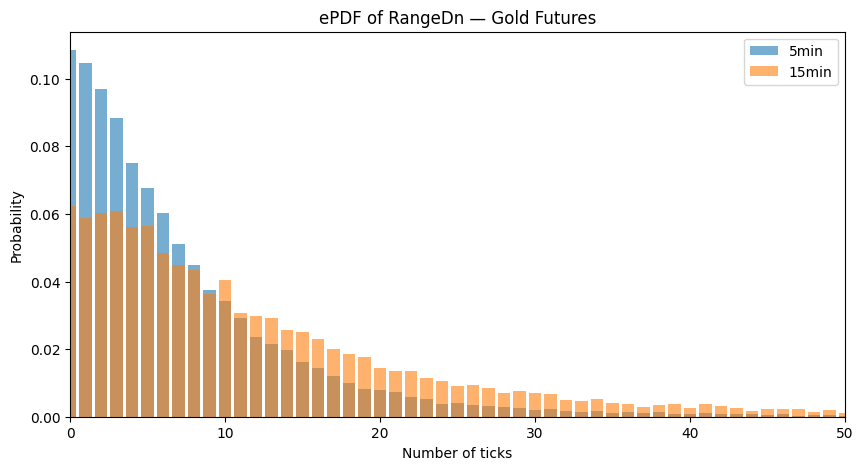

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(epdfs_5min["range_dn"].index, epdfs_5min["range_dn"].values, 
       alpha=0.6, label="5min")
ax.bar(epdfs_15min["range_dn"].index, epdfs_15min["range_dn"].values, 
       alpha=0.6, label="15min")

ax.set_xlabel("Number of ticks")
ax.set_ylabel("Probability")
ax.set_title("ePDF of RangeDn — Gold Futures")
ax.set_xlim(0, 50)  # zoom in, tail is very small
ax.legend()
plt.show()

In [35]:
# STEP 4

In [39]:
import numpy as np

def compute_ewma(series, m):
    values = series.astype(float).to_numpy()
    
    lambda_ = 2 ** (-1 / m)

    ewma = np.zeros(len(values))
    ewmv = np.zeros(len(values))

    sumW = 0.0
    sumWX = 0.0
    sumWSS = 0.0

    # First row has no previous observation to use
    ewma[0] = np.nan
    ewmv[0] = np.nan

    for j in range(1, len(values)):
        # Use eta_{j-1}, not eta_j
        prev_x = values[j - 1]

        sumW = lambda_ * sumW + 1
        sumWX = lambda_ * sumWX + prev_x

        ewma[j] = sumWX / sumW

        sumWSS = lambda_ * sumWSS + (prev_x - ewma[j]) ** 2
        ewmv[j] = np.sqrt(sumWSS / sumW)

    return pd.DataFrame({
        "ewma": ewma,
        "ewmv": ewmv
    }, index=series.index)

In [40]:
volume_state = compute_ewma(df_5min["volume"], m=10)
range_state = compute_ewma(df_5min["range_ticks"], m=10)

print(volume_state.head())
print(range_state.head())

        ewma      ewmv
0        NaN       NaN
1  51.000000  0.000000
2  47.378748  2.430167
3  52.237263  5.584585
4  49.406033  6.142598
       ewma      ewmv
0       NaN       NaN
1  7.000000  0.000000
2  4.930713  1.388667
3  5.312113  1.187158
4  4.672672  1.339159


In [41]:
df_5min[["ewma_volume", "ewmv_volume"]] = volume_state
df_5min[["ewma_range", "ewmv_range"]] = range_state

print(df_5min.head())

             datetime    open    high     low   close  volume  range_ticks  \
0 2023-11-27 00:00:00  2034.2  2034.7  2034.0  2034.7      51            7   
1 2023-11-27 00:05:00  2034.6  2034.9  2034.6  2034.6      44            3   
2 2023-11-27 00:10:00  2034.6  2034.9  2034.3  2034.9      61            6   
3 2023-11-27 00:15:00  2034.8  2034.9  2034.6  2034.7      42            3   
4 2023-11-27 00:20:00  2034.7  2034.7  2034.1  2034.3      93            6   

   range_up  range_dn  ewma_volume  ewmv_volume  ewma_range  ewmv_range  
0         5         2          NaN          NaN         NaN         NaN  
1         3         0    51.000000     0.000000    7.000000    0.000000  
2         3         3    47.378748     2.430167    4.930713    1.388667  
3         1         2    52.237263     5.584585    5.312113    1.187158  
4         0         6    49.406033     6.142598    4.672672    1.339159  


In [42]:
# Bin EWMA volume and range into 3 percentile-based states

df_5min["vol_state"] = pd.qcut(
    df_5min["ewma_volume"],
    q=3,
    labels=[1, 2, 3]
)

df_5min["range_state"] = pd.qcut(
    df_5min["ewma_range"],
    q=3,
    labels=[1, 2, 3]
)

print(df_5min[[
    "datetime",
    "ewma_volume",
    "vol_state",
    "ewma_range",
    "range_state"
]].head(10))

print(df_5min["vol_state"].value_counts().sort_index())
print(df_5min["range_state"].value_counts().sort_index())

             datetime  ewma_volume vol_state  ewma_range range_state
0 2023-11-27 00:00:00          NaN       NaN         NaN         NaN
1 2023-11-27 00:05:00    51.000000         1    7.000000           1
2 2023-11-27 00:10:00    47.378748         1    4.930713           1
3 2023-11-27 00:15:00    52.237263         1    5.312113           1
4 2023-11-27 00:20:00    49.406033         1    4.672672           1
5 2023-11-27 00:25:00    59.373343         1    4.976152           1
6 2023-11-27 00:30:00    91.775056         1    8.129956           1
7 2023-11-27 00:35:00   110.453554         1    8.978313           1
8 2023-11-27 00:40:00   107.078298         1    8.352411           1
9 2023-11-27 00:45:00    96.533814         1    8.301562           1
vol_state
1    12144
2    12143
3    12144
Name: count, dtype: int64
range_state
1    12144
2    12143
3    12144
Name: count, dtype: int64


In [44]:
# Note: qcut uses global percentiles — acceptable for now but 
# ideally bin boundaries should be computed on a rolling basis
# to avoid forward-looking bias

# Compute trend / price change state
df_5min["delta_x"] = df_5min["open"].diff()

# Bin into 3 states: down / flat / up
df_5min["trend_state"] = pd.qcut(
    df_5min["delta_x"],
    q=3,
    labels=[1, 2, 3]
)

# Check results
print(df_5min[[
    "datetime",
    "open",
    "delta_x",
    "trend_state"
]].head(10))

print(df_5min["trend_state"].value_counts().sort_index())

             datetime    open  delta_x trend_state
0 2023-11-27 00:00:00  2034.2      NaN         NaN
1 2023-11-27 00:05:00  2034.6      0.4           3
2 2023-11-27 00:10:00  2034.6      0.0           2
3 2023-11-27 00:15:00  2034.8      0.2           2
4 2023-11-27 00:20:00  2034.7     -0.1           2
5 2023-11-27 00:25:00  2034.2     -0.5           1
6 2023-11-27 00:30:00  2032.1     -2.1           1
7 2023-11-27 00:35:00  2032.7      0.6           3
8 2023-11-27 00:40:00  2032.7      0.0           2
9 2023-11-27 00:45:00  2033.0      0.3           2
trend_state
1    12459
2    12496
3    11476
Name: count, dtype: int64


In [45]:
# STEP 5

In [46]:
state_counts = df_5min.groupby(
    ["vol_state", "range_state", "trend_state"]
).size().reset_index(name="count")

print(state_counts)
print("Total combinations:", len(state_counts))

   vol_state range_state trend_state  count
0          1           1           1   2347
1          1           1           2   4915
2          1           1           3   2063
3          1           2           1    993
4          1           2           2    912
5          1           2           3    903
6          1           3           1      3
7          1           3           2      2
8          1           3           3      6
9          2           1           1    760
10         2           1           2   1250
11         2           1           3    618
12         2           2           1   2553
13         2           2           2   2281
14         2           2           3   2277
15         2           3           1    955
16         2           3           2    532
17         2           3           3    917
18         3           1           1     58
19         3           1           2     80
20         3           1           3     53
21         3           2        

In [66]:
def compute_conditional_epdfs(df, min_count=30):
    cond_epdfs = {}
    grouped = df.groupby(["vol_state", "range_state", "trend_state"])
    
    for state, group in grouped:
        if len(group) < min_count:
            continue
        cond_epdfs[state] = {
            "range_dn": (group["range_dn"].value_counts() / len(group)).sort_index(),
            "range_up": (group["range_up"].value_counts() / len(group)).sort_index()
        }
    
    print(f"Valid state combinations: {len(cond_epdfs)} / 27")
    return cond_epdfs

cond_epdfs = compute_conditional_epdfs(df_5min)

Valid state combinations: 24 / 27


In [67]:
# Low vol, low volume, downtrend
state_low = (1, 1, 1)
# High vol, high volume, uptrend
state_high = (3, 3, 3)

print("Low state ePDF (first 10 ticks):")
print(cond_epdfs[state_low]["range_dn"].head(10))

print("\nHigh state ePDF (first 10 ticks):")
print(cond_epdfs[state_high]["range_dn"].head(10))

print("Mean range_dn — low state:", 
      np.sum(cond_epdfs[state_low]["range_dn"].index.astype(float) * cond_epdfs[state_low]["range_dn"].values).round(2))
print("Mean range_dn — high state:", 
      np.sum(cond_epdfs[state_high]["range_dn"].index.astype(float) * cond_epdfs[state_high]["range_dn"].values).round(2))

Low state ePDF (first 10 ticks):
range_dn
0    0.138049
1    0.152961
2    0.132510
3    0.119301
4    0.095441
5    0.082233
6    0.061781
7    0.051129
8    0.038773
9    0.032808
Name: count, dtype: float64

High state ePDF (first 10 ticks):
range_dn
0    0.064311
1    0.052110
2    0.052872
3    0.054143
4    0.047789
5    0.053127
6    0.050839
7    0.047026
8    0.045247
9    0.038383
Name: count, dtype: float64
Mean range_dn — low state: 4.37
Mean range_dn — high state: 12.45


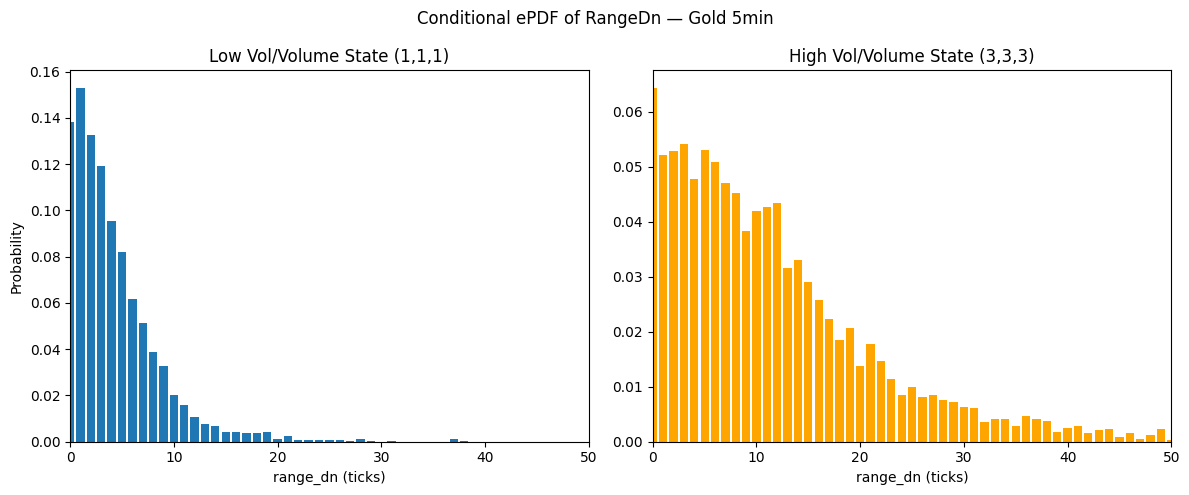

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Low state
axes[0].bar(cond_epdfs[state_low]["range_dn"].index, cond_epdfs[state_low]["range_dn"].values)
axes[0].set_xlim(0, 50)
axes[0].set_title("Low Vol/Volume State (1,1,1)")
axes[0].set_xlabel("range_dn (ticks)")
axes[0].set_ylabel("Probability")

# High state
axes[1].bar(cond_epdfs[state_high]["range_dn"].index, cond_epdfs[state_high]["range_dn"].values, color="orange")
axes[1].set_xlim(0, 50)
axes[1].set_title("High Vol/Volume State (3,3,3)")
axes[1].set_xlabel("range_dn (ticks)")

plt.suptitle("Conditional ePDF of RangeDn — Gold 5min")
plt.tight_layout()
plt.show()

In [59]:
# ORDER PLACEMENT LOGIC

In [60]:
from datetime import datetime, timedelta

def load_signals(filepath):
    df = pd.read_csv(filepath, header=None,
                     names=["date_serial", "hour", "minute", "price", "signal"])
    
    excel_epoch = datetime(1899, 12, 30)
    df["datetime"] = df.apply(
        lambda r: excel_epoch
                  + timedelta(days=int(r["date_serial"]))
                  + timedelta(hours=int(r["hour"]))
                  + timedelta(minutes=int(r["minute"])),
        axis=1
    )
    
    df["signal_direction"] = df["signal"].apply(
        lambda s: "buy" if s > 0 else ("sell" if s < 0 else "flat")
    )
    
    return df[["datetime", "price", "signal", "signal_direction"]].sort_values("datetime").reset_index(drop=True)

signals = load_signals("data/Gold/AIAgent_Gold.csv")
print(signals.head(10))
print(signals["signal_direction"].value_counts())

             datetime   price  signal signal_direction
0 2024-01-02 00:00:00  2078.6       0             flat
1 2024-01-02 00:05:00  2078.7       0             flat
2 2024-01-02 00:10:00  2079.3       0             flat
3 2024-01-02 00:15:00  2080.5       0             flat
4 2024-01-02 00:20:00  2079.9       0             flat
5 2024-01-02 00:25:00  2080.2       0             flat
6 2024-01-02 00:30:00  2080.5       0             flat
7 2024-01-02 00:35:00  2080.6       0             flat
8 2024-01-02 00:40:00  2080.2       0             flat
9 2024-01-02 00:45:00  2080.9       0             flat
signal_direction
buy     18784
sell     6500
flat     5773
Name: count, dtype: int64


In [53]:
# Keep only non-flat signals
active_signals = signals[signals["signal_direction"] != "flat"].copy()

# Merge with df_5min to get the state at each signal time
df_signals = active_signals.merge(
    df_5min[["datetime", "vol_state", "range_state", "trend_state", "open"]],
    on="datetime",
    how="inner"
)

print(f"Signals before merge: {len(active_signals)}")
print(f"Signals after merge: {len(df_signals)}")
print(df_signals.head())

Signals before merge: 25284
Signals after merge: 19636
             datetime   price  signal signal_direction vol_state range_state  \
0 2024-01-02 01:30:00  2084.4      -1             sell         2           2   
1 2024-01-02 01:35:00  2084.0      -1             sell         2           2   
2 2024-01-02 01:40:00  2083.7      -1             sell         2           2   
3 2024-01-02 01:45:00  2083.6      -1             sell         2           2   
4 2024-01-02 01:50:00  2083.4      -1             sell         2           2   

  trend_state    open  
0           3  2084.4  
1           1  2084.0  
2           1  2083.6  
3           2  2083.7  
4           1  2083.3  


In [54]:
def get_order_recommendation(signal_direction, open_price, state, 
                              cond_epdfs, tick_size=0.10, target_prob=0.70):
    
    # Pick correct ePDF based on signal direction
    if signal_direction == "buy":
        epdf = cond_epdfs[state].get("range_dn") if isinstance(cond_epdfs[state], dict) else cond_epdfs[state]
        direction = -1  # place below open
    else:
        epdf = cond_epdfs[state].get("range_up") if isinstance(cond_epdfs[state], dict) else cond_epdfs[state]
        direction = 1   # place above open
    
    if epdf is None:
        return None
    
    # Compute survival function P(range >= k)
    cumulative = epdf.sort_index().cumsum()
    survival = 1 - cumulative
    
    # Find k where survival probability >= target
    valid = survival[survival >= target_prob]
    if len(valid) == 0:
        k = 0
    else:
        k = valid.index[-1]
    
    limit_price = open_price + direction * k * tick_size
    
    return {
        "limit_price": round(limit_price, 2),
        "ticks_away": k,
        "fill_probability": round(survival.get(k, 0), 3)
    }

In [55]:
# Test on first buy signal
row = df_signals[df_signals["signal_direction"] == "buy"].iloc[0]
state = (row["vol_state"], row["range_state"], row["trend_state"])
result = get_order_recommendation("buy", row["open"], state, cond_epdfs)
print("Buy recommendation:", result)

# Test on first sell signal  
row = df_signals[df_signals["signal_direction"] == "sell"].iloc[0]
state = (row["vol_state"], row["range_state"], row["trend_state"])
result = get_order_recommendation("sell", row["open"], state, cond_epdfs)
print("Sell recommendation:", result)

Buy recommendation: {'limit_price': np.float64(2083.6), 'ticks_away': np.int64(1), 'fill_probability': np.float64(0.772)}
Sell recommendation: {'limit_price': np.float64(2084.6), 'ticks_away': np.int64(2), 'fill_probability': np.float64(0.734)}


In [69]:
df_signals["limit_price"] = None
df_signals["ticks_away"] = None
df_signals["fill_probability"] = None

for idx, row in df_signals.iterrows():
    state = (row["vol_state"], row["range_state"], row["trend_state"])
    if state not in cond_epdfs:
        continue
    result = get_order_recommendation(
        row["signal_direction"], 
        row["open"], 
        state, 
        cond_epdfs
    )
    if result:
        df_signals.at[idx, "limit_price"] = result["limit_price"]
        df_signals.at[idx, "ticks_away"] = result["ticks_away"]
        df_signals.at[idx, "fill_probability"] = result["fill_probability"]

print(df_signals.head(10))
print("Signals with recommendations:", df_signals["limit_price"].notna().sum())

             datetime   price  signal signal_direction vol_state range_state  \
0 2024-01-02 01:30:00  2084.4      -1             sell         2           2   
1 2024-01-02 01:35:00  2084.0      -1             sell         2           2   
2 2024-01-02 01:40:00  2083.7      -1             sell         2           2   
3 2024-01-02 01:45:00  2083.6      -1             sell         2           2   
4 2024-01-02 01:50:00  2083.4      -1             sell         2           2   
5 2024-01-02 01:55:00  2082.5      -1             sell         2           2   
6 2024-01-02 02:00:00  2082.7      -1             sell         2           2   
7 2024-01-02 02:05:00  2082.9      -1             sell         2           2   
8 2024-01-02 02:10:00  2083.6      -1             sell         2           2   
9 2024-01-02 02:15:00  2083.9      -1             sell         2           2   

  trend_state    open limit_price ticks_away fill_probability  
0           3  2084.4      2084.6          2           

In [72]:
# Add metadata columns for backtester
df_signals["tau"] = 5
df_signals["tick_size"] = 0.10

# Carry contract through from stitched 1-min data
contract_map = df_stitched[["datetime", "contract"]].copy()
contract_map = contract_map.drop_duplicates(subset="datetime")
df_signals = df_signals.merge(contract_map, on="datetime", how="left")

# Add human readable state labels
vol_map = {1: "low", 2: "medium", 3: "high"}
range_map = {1: "low", 2: "medium", 3: "high"}
trend_map = {1: "down", 2: "flat", 3: "up"}

df_signals["vol_state_label"] = df_signals["vol_state"].map(vol_map)
df_signals["range_state_label"] = df_signals["range_state"].map(range_map)
df_signals["trend_state_label"] = df_signals["trend_state"].map(trend_map)

# Export
df_signals.to_csv("data/Gold/GC_signals_with_recommendations.csv", index=False)
print("Saved successfully")
print(df_signals.columns.tolist())

Saved successfully
['datetime', 'price', 'signal', 'signal_direction', 'vol_state', 'range_state', 'trend_state', 'open', 'limit_price', 'ticks_away', 'fill_probability', 'tau', 'tick_size', 'contract', 'vol_state_label', 'range_state_label', 'trend_state_label']


In [74]:
df_signals.to_csv("data/Gold/GC_signals_with_recommendations.csv", index=False)
print("Saved successfully")

Saved successfully
